# Automatic Differentiation and Backpropagation

In this notebook we implement **automatic differentiation (autograd)** and **backpropagation**
from scratch, then compare against PyTorch's autograd.

This is the engine behind training: it computes the gradient of the loss with respect to
*every* parameter, no matter how complex the function, without us deriving any formula by hand.

**Roadmap**
1. Derivatives — the numerical and analytical view
2. Why we need gradients (gradient descent)
3. The chain rule on a computation graph
4. A scalar autograd engine: the `Value` class
5. Building and training a tiny MLP with it
6. Cross-check with PyTorch autograd
7. Generalizing to tensors: the `TensorValue` class

**References**
- Andrej Karpathy — *The spelled-out intro to backpropagation* ([video](https://www.youtube.com/watch?v=VMj-3S1tku0)), [`micrograd`](https://github.com/karpathy/micrograd)
- [PyTorch autograd tutorial](https://docs.pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html)

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Derivatives of a Function

We start with the definition of a derivative and check it numerically against the analytical formula.

f(2) = 9


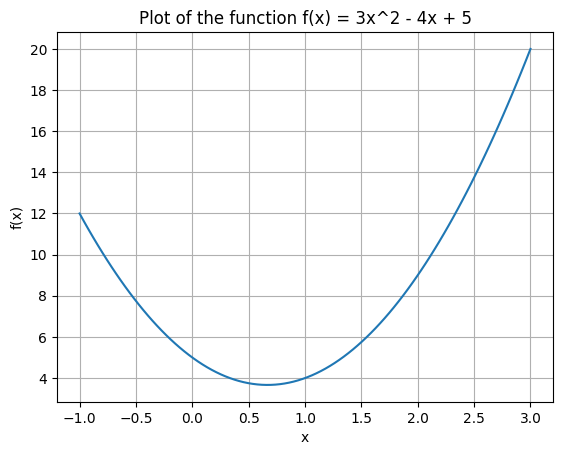

In [2]:
#lets define a function
def f(x):
  return 3*x**2 - 4*x + 5

print("f(2) =", f(2))

# visualize the function
xi = np.linspace(-1, 3, 100) # 100 points between -2 and 4

def visualize_function(f, xi):
    yi = f(xi)
    plt.plot(xi, yi)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Plot of the function f(x) = 3x^2 - 4x + 5')
    plt.grid(True)
    plt.show()
visualize_function(f, xi)

In [3]:
# compute the derivative of f(x) at x=2 using the definition of the derivative

#define the real derivative of f(x) for comparison
def df(x):
  return 6*x - 4

#calculate the derivative of f(x) using the definition of the derivative
# df(x) = lim h->0 (f(x+h) - f(x)) / h

def derivative(f,x):
  h = 1e-5 # a small number
  return (f(x + h) - f(x)) / h

x = 2
numerical_derivative = derivative(f, x)
analytical_derivative = df(x)
print(f"Numerical derivative of f(x) at x={x} is approximately {numerical_derivative}")
print(f"Analytical derivative of f(x) at x={x} is {analytical_derivative}")

Numerical derivative of f(x) at x=2 is approximately 8.000030000054892
Analytical derivative of f(x) at x=2 is 8


## 2. Why Compute Derivatives?

In machine learning we want to **minimize a loss function**. The derivative of the loss with
respect to each model parameter tells us *how to nudge that parameter to reduce the loss*:
move opposite to the gradient. This is **gradient descent**, the core training loop.

In [4]:
#Lets give a sense how to use derivate to optimize the function f(x) using gradient descent( find the minimum of the function)
x = np.random.rand() * 6 - 2 # random starting point between -2 and 4
learning_rate = 0.1
for epoch in range(100):
    grad = df(x) # compute the gradient at the current point
    x = x - learning_rate * grad # update x in the direction of the negative gradient
    if epoch % 20 == 0: # print every 20 epochs
        print(f"Epoch {epoch}: x = {x}, f(x) = {f(x)}")

print(f"Minimum value of f(x) is approximately {f(x)} at x = {x}")

Epoch 0: x = 0.7328968259418165, f(x) = 3.6798259686595016
Epoch 20: x = 0.666666667394875, f(x) = 3.666666666666667
Epoch 40: x = 0.6666666666666667, f(x) = 3.6666666666666665
Epoch 60: x = 0.6666666666666667, f(x) = 3.6666666666666665
Epoch 80: x = 0.6666666666666667, f(x) = 3.6666666666666665
Minimum value of f(x) is approximately 3.6666666666666665 at x = 0.6666666666666667


In [4]:
#Now, lets define a more complex function of of two variables:
# f(x,y)  = 3*x**2 + 2*y**2 - 4*x*y + 5
def f(x,y):
  return 3*x**2 + 2*y**2 - 4*x*y + 5

# compute the analytical gradients of f(x,y)
def df_dx(x,y):
  return 6*x - 4*y
def df_dy(x,y):
  return 4*y - 4*x

# compute the numerical gradients of f(x,y) using the definition of the derivative
def derivative_x(f,x,y):
    h = 1e-5 # a small number
    return (f(x + h, y) - f(x, y)) / h

def derivative_y(f,x,y):
    h = 1e-5 # a small number
    return (f(x, y + h) - f(x, y)) / h

# compute the gradients at a specific point (x,y) = (1,1)
x,y = 1, 1
numerical_df_dx = derivative_x(f, x, y)
numerical_df_dy = derivative_y(f, x, y)
analytical_df_dx = df_dx(x, y)
analytical_df_dy = df_dy(x, y)
print(f"Numerical gradient df/dx at (x,y) = ({x},{y}) is approximately {numerical_df_dx} (real value is {analytical_df_dx})")
print(f"Numerical gradient df/dy at (x,y) = ({x},{y}) is approximately {numerical_df_dy} (real value is {analytical_df_dy})")

Numerical gradient df/dx at (x,y) = (1,1) is approximately 2.0000300000155846 (real value is 2)
Numerical gradient df/dy at (x,y) = (1,1) is approximately 2.000000165480742e-05 (real value is 0)


## 3. The Chain Rule on a Computation Graph

For functions of a few variables we can differentiate by hand. But models have **millions**
of parameters — manual derivation is impossible. **Automatic differentiation** solves this by
applying the **chain rule** mechanically over the graph of elementary operations.

Take this small example:

$$e = a\cdot b \qquad d = e + c \qquad f = 3\cdot d = 3(a b + c)$$

As a computation graph:

```
(a) ---- * (e) --- + (d) --- * (f)
        /         /         /
      (b)       (c)       (3)
```

**Local derivatives** (each node w.r.t. its inputs):

$$\frac{\partial f}{\partial f}=1,\quad \frac{\partial f}{\partial d}=3,\quad \frac{\partial d}{\partial e}=1,\quad \frac{\partial d}{\partial c}=1,\quad \frac{\partial e}{\partial a}=b,\quad \frac{\partial e}{\partial b}=a$$

**Propagate from the output back to the inputs** (multiply along each path — the chain rule):

$$\frac{\partial f}{\partial e}=\frac{\partial f}{\partial d}\frac{\partial d}{\partial e}=3,\qquad \frac{\partial f}{\partial c}=\frac{\partial f}{\partial d}\frac{\partial d}{\partial c}=3$$

$$\frac{\partial f}{\partial a}=\frac{\partial f}{\partial d}\frac{\partial d}{\partial e}\frac{\partial e}{\partial a}=3b,\qquad \frac{\partial f}{\partial b}=3a$$

The key idea of **backpropagation**: start at the output (with gradient 1) and walk the graph
**backward**, multiplying local derivatives along the way. To implement this, we give each
value a class that stores its number **and** how to push gradients to its inputs.

In [5]:
class Value:
    def __init__(self, value, _children=(), _op='', label=''):
        """
        children: the Value objects that were used to compute this Value
        op: the operation that was used to compute this Value (e.g., '+', '*', etc.)
        """
        self.value = value
        # self.grad = d out/ d self
        #grad is the gradient of the output (final value of the computation) with respect to this Value,
        #  which will be computed during backpropagation
        self.grad = 0 
        self._children = _children
        self._op = _op
        self._backward = lambda: None
        self.label = label

    def __add__(self, other):
        #convert other to a Value if it is not already a Value (e.g., if other is a number)
        other = other if isinstance(other, Value) else Value(other, label='('+str(other)+')')
        #out = self.value + other.value (local output)
        out = Value(self.value + other.value, _children=(self, other), _op='+', label=f"{self.label}+{other.label}")
        #f = final output of the computation
        #d out/ d self = 1 and  d out/ d other = 1
        # d f/ d self = d f/ d out * d out/ d self = d f/ d out * 1 = d f/ d out
        # d f/ d other = d f/ d out * d out/ d other = d f/ d out * 1 = d f/ d out
        def _backward():
            #we add to the gradients of self and other because they might be used in multiple places in the computation graph, 
            # so we need to accumulate the gradients from all the paths that lead to self and other
            self.grad += 1 * out.grad
            other.grad += 1 * out.grad
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __truediv__(self, other):
        #a/b -> a*(1/b) -> a*(b**-1)
        return self * other**-1
    
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other, label='('+str(other)+')')
        #out = self.value * other.value (local output)
        out = Value(self.value * other.value, _children=(self, other), _op='*', label=f"{self.label}*{other.label}")
        #f = final output of the computation graph
        # d out/ d self = other.value and  d out/ d other = self.value
        # d f/ d self = d f/ d out * d out/ d self = d f/ d out * other.value
        # d f/ d other = d f/ d out * d out/ d other = d f/ d out * self.value
        def _backward():
            self.grad += other.value * out.grad
            other.grad += self.value * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        #out = self.value ** other (local output)
        out = Value(self.value ** other, _children=(self,), _op=f'**{other}', label=f"{self.label}**{other}")
        #f = final output of the computation graph
        # d out/ d self = other * self.value ** (other - 1)
        # d f/ d self = d f/ d out * d out/ d self = d f/ d out * other * self.value ** (other - 1)
        def _backward():
            self.grad += other * self.value ** (other - 1) * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        #out = tanh(self.value) (local output)
        x = self.value
        _tanh = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(_tanh, _children=(self,), _op='tanh', label=f"tanh({self.label})")
        #f = final output of the computation graph
        # d out/ d self = 1 - tanh(self.value)**2
        # d f/ d self = d f/ d out * d out/ d self = d f/ d out * (1 - tanh(self.value)**2)
        def _backward():
            self.grad += (1 - _tanh**2) * out.grad
        out._backward = _backward
        return out
    
    def exp(self):
        #out = exp(self.value) (local output)
        x = self.value
        _exp = math.exp(x)
        out = Value(_exp, _children=(self,), _op='exp', label=f"exp({self.label})")
        #f = final output of the computation graph
        # d out/ d self = exp(self.value)
        # d f/ d self = d f/ d out * d out/ d self = d f/ d out * exp(self.value)
        def _backward():
            self.grad += _exp * out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

    def __rmul__(self, other):
        return self * other

    def __repr__(self):
        return f"Value(value={self.value}, grad={self.grad}, label={self.label})"
    
    def __str__(self):
        return f"{self.value}"

In [39]:
#Function to visualize the computation graph using graphviz
#source:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._children:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.value, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [8]:
# lets test the implementation of the Value class and the draw_dot function
#f = 3*d = 3*(e+c) = 3*(a*b + c) = 3ab + 3c
a = Value(2.0, label='a')
b = Value(3.0, label='b')
c = Value(4.0, label='c')
e = a*b
e.label = 'e'
d = e+c
d.label = 'd'
f = 3*d
f.label = 'f'

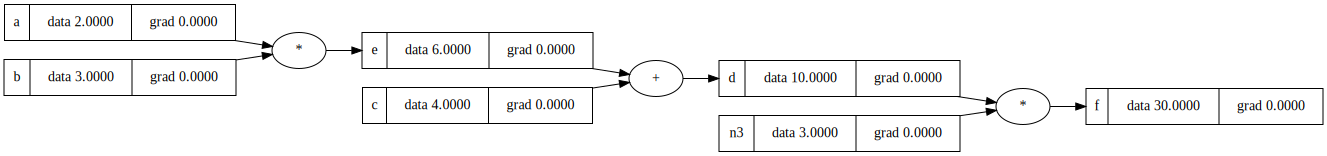

In [9]:
draw_dot(f)

In [10]:
# Calculate the gradients of f with respect to a, b, and c using backpropagation
f.grad = 1.0 # d f/ d f = 1
f._backward() # compute the gradients of f with respect to d and '3'
print(f"df/df = {f.grad}, df/dd = {d.grad}")
d._backward() # compute the gradients of d with respect to e and c
print(f"df/de = {e.grad}, df/dc = {c.grad}")
e._backward() # compute the gradients of e with respect to a and b
print(f"df/da = {a.grad}, df/db = {b.grad}")

df/df = 1.0, df/dd = 3.0
df/de = 3.0, df/dc = 3.0
df/da = 9.0, df/db = 6.0


### Automating backprop with topological order

Calling `_backward()` on every node by hand is tedious. Instead, we call `backward()` once on
the **final output**, and it propagates to all nodes automatically.

The trick is to process nodes in **reverse topological order** — a node's gradient must be
fully accumulated before it passes gradient to its inputs. Here the order is
`f → d → e → a, b, c`. We add a `backward()` method to `Value` that topologically sorts the
graph and calls each node's `_backward()` in the correct order.

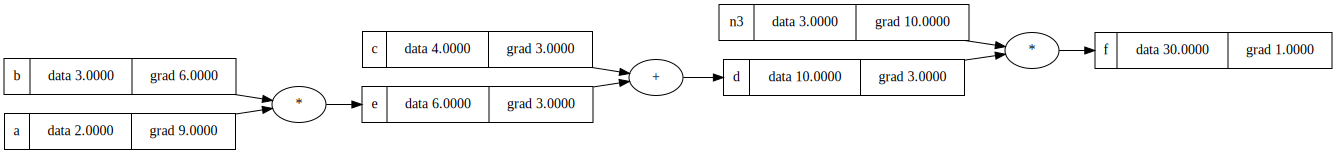

In [11]:
# Lets calculate again the gradients 
# lets test the implementation of the Value class and the draw_dot function
#f = 3*d = 3*(e+c) = 3*(a*b + c) = 3ab + 3c
a = Value(2.0, label='a')
b = Value(3.0, label='b')
c = Value(4.0, label='c')
e = a*b
e.label = 'e'
d = e+c
d.label = 'd'
f = 3*d
f.label = 'f'
f.grad = 1.0 # d f/ d f = 1
f.backward() # compute the gradients of f with respect to all the variables in the graph
draw_dot(f)


In [12]:
# Compute the numerical gradients using finite differences
def check():
    a = Value(1.0, label="a")
    b = Value(2.0, label="b")
    c = Value(3.0, label="c")
    d = Value(4.0, label="d")

    # Compute the function value
    f1= a*b + 3*c*d
    f1.label = 'f1'
    
    h = 0.0001
    a = Value(1.0, label="a")
    b = Value(2.0, label="b")
    c = Value(3.0, label="c")
    d = Value(4.0+h, label="d")

    # Compute the function value
    f2 = a*b + 3*c*d
    f2.label = 'f2'

    return (f2.value - f1.value) / h

check() # check df/dd

9.000000000014552

## 4. A Tiny Neuron

We now use `Value` to build and visualize the forward + backward pass of a single neuron with
two inputs, weights, and a bias:

```
(x1) ---- * (w1,w2) ---- + (a) --- tanh (y)
         /              /
       (x2)           (b)
```

$$y = \tanh(x \cdot w^\top + b)$$

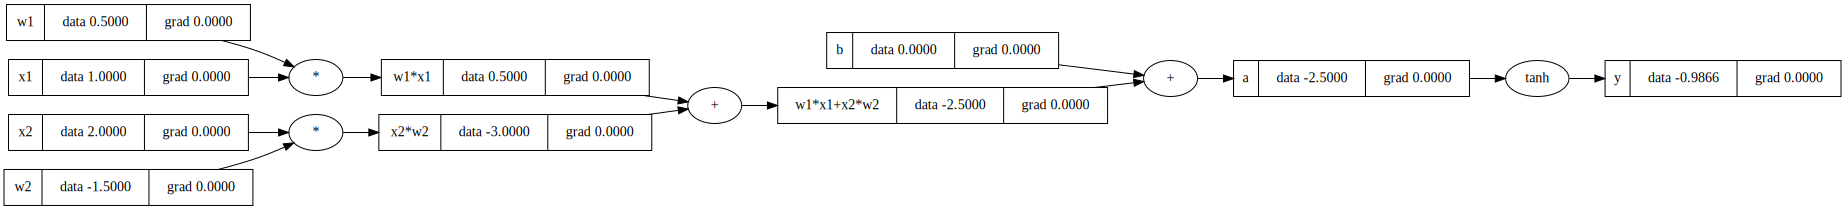

In [13]:
#inputs x1 and x2
x1 = Value(1.0, label='x1')
x2 = Value(2.0, label='x2')
#weights w1 and w2
w1 = Value(0.5, label='w1')
w2 = Value(-1.5, label='w2')
#bias
b = Value(0.0, label='b')

w1x1 = w1 * x1
x2w2 = x2 * w2
a = w1x1 + x2w2 + b
a.label = 'a'
y = a.tanh()
y.label = 'y'
draw_dot(y)


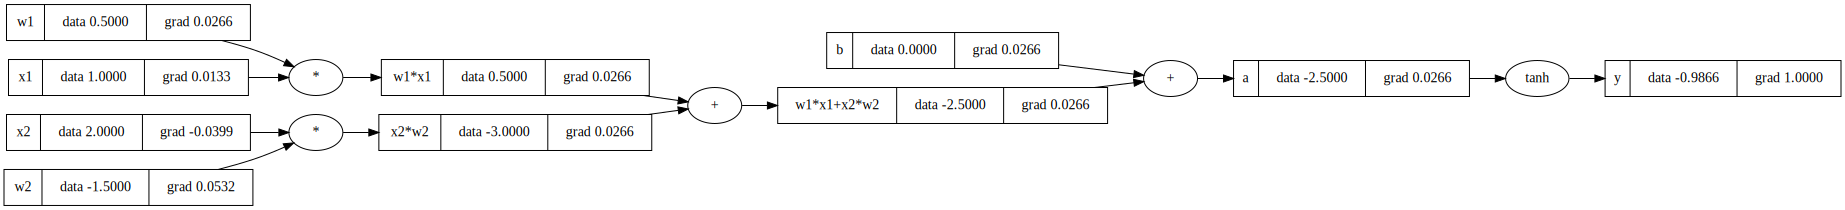

In [14]:
y.backward()
draw_dot(y)

In [15]:
import torch

In [18]:
#Lets implement the same computation graph using PyTorch tensors and autograd
x1 = torch.tensor(1.0, requires_grad=True)
x2 = torch.tensor(2.0, requires_grad=True)
w1 = torch.tensor(0.5, requires_grad=True)
w2 = torch.tensor(-1.5, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
w1x1 = w1 * x1
x2w2 = x2 * w2
a = w1x1 + x2w2 + b
y = a.tanh()
y.backward()
print(f"x1.grad = {x1.grad: .3f}, x2.grad = {x2.grad: .3f}, w1.grad = {w1.grad: .3f}, w2.grad = {w2.grad: .3f}, b.grad = {b.grad: .3f}")

x1.grad =  0.013, x2.grad = -0.040, w1.grad =  0.027, w2.grad =  0.053, b.grad =  0.027


In [52]:
# Now, we going to implement a simple feedforward neural network using the Value class and backpropagation to train it on a simple dataset.
class Neuron:
    def __init__(self, nin):
        self.w = [Value(np.random.randn(), label=f'w{i}') for i in range(nin)]
        self.b = Value(0.0, label='b')
    
    def __call__(self, x):
        # compute the weighted sum of the inputs and the bias
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh() # apply the activation function
        return out

    def parameters(self):
        return self.w +[self.b]
    
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts # e.g., if nin=3 and nouts=[4,2], then sz=[3,4,2]
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0

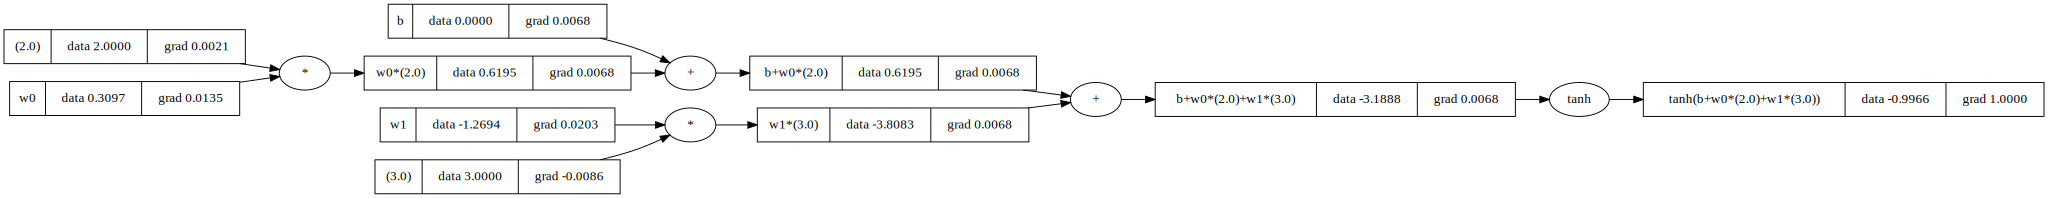

In [43]:
x = [2.0, 3.0]
n = Neuron(2)
out = n(x)
out.backward()
draw_dot(out)

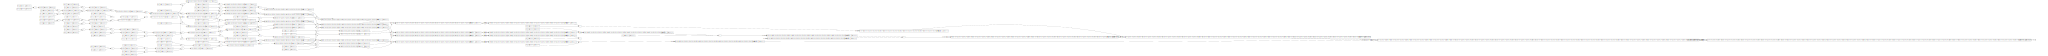

In [46]:
x = [2.0, 3.0, -1.0]
mlp = MLP(3, [4, 4,1])
out = mlp(x)
out
out[0].backward()
draw_dot(out[0])

In [60]:
#Lets train the MLP on a simple dataset
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

model = MLP(3, [4, 4, 1])

for epoch in range(100):

    ypred = [model(x)[0] for x in xs]
    loss = sum((yp - y) ** 2 for yp, y in zip(ypred, ys))
    model.zero_grad()
    loss.backward()
    for p in model.parameters():
        p.value += -0.01 * p.grad
        
    print(f"Epoch {epoch}, loss: {loss.value:.4f}")

Epoch 0, loss: 7.8541
Epoch 1, loss: 7.3229
Epoch 2, loss: 6.3629
Epoch 3, loss: 4.7649
Epoch 4, loss: 4.0433
Epoch 5, loss: 3.5072
Epoch 6, loss: 0.8004
Epoch 7, loss: 0.3334
Epoch 8, loss: 0.2918
Epoch 9, loss: 0.2590
Epoch 10, loss: 0.2325
Epoch 11, loss: 0.2107
Epoch 12, loss: 0.1925
Epoch 13, loss: 0.1770
Epoch 14, loss: 0.1638
Epoch 15, loss: 0.1524
Epoch 16, loss: 0.1424
Epoch 17, loss: 0.1336
Epoch 18, loss: 0.1259
Epoch 19, loss: 0.1189
Epoch 20, loss: 0.1127
Epoch 21, loss: 0.1071
Epoch 22, loss: 0.1020
Epoch 23, loss: 0.0974
Epoch 24, loss: 0.0932
Epoch 25, loss: 0.0894
Epoch 26, loss: 0.0858
Epoch 27, loss: 0.0826
Epoch 28, loss: 0.0796
Epoch 29, loss: 0.0768
Epoch 30, loss: 0.0741
Epoch 31, loss: 0.0717
Epoch 32, loss: 0.0695
Epoch 33, loss: 0.0673
Epoch 34, loss: 0.0653
Epoch 35, loss: 0.0635
Epoch 36, loss: 0.0617
Epoch 37, loss: 0.0600
Epoch 38, loss: 0.0585
Epoch 39, loss: 0.0570
Epoch 40, loss: 0.0556
Epoch 41, loss: 0.0542
Epoch 42, loss: 0.0530
Epoch 43, loss: 0.051

In [ ]:
#HOW TO AUTOGRAD WORKS IN PYTORCH
# Estimates the gradient of f(x)=x^2 at points [-2, -1, 1, 4]
#1) USING GRADIENT FUNCTION
#using nearest neighbor spacing is it possible to estimate the gradient more precisely
x = (torch.tensor([-2.1, -2., -1.1, -1., 1.,1.1, 4., 4.1]),) #formatting to make x a tuple

#f(x) = x^2
def f(x):
    return x**2

#evalueate y
y = f(x[0])
# Estimates the gradient of f(x)=x^2 at points [-2, -1, 2, 4]
y_grad = torch.gradient(y, spacing = x)
print("using torch.gradient:", y_grad)
#-------------------------------------------------------------------------------

#2) USING AUTOGRAD, NOT STORING .GRAD IN X
x = torch.tensor([-2.1, -2., -1.1, -1., 1.,1.1, 4., 4.1], requires_grad=True)
y = f(x)
x.grad = None  # reset gradients
#calculate gradients using autograd.grad. grad_outputs is needed when y is not a scalar
g = torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y))
print("using torch.autograd.grad:", g)
#-------------------------------------------------------------------------------

# 3) USING AUTOGRAD, STORING .GRAD IN X 
# Using autograd to compute the gradient of f(x)=x^2
x = torch.tensor([-2.1, -2., -1.1, -1., 1.,1.1, 4., 4.1], requires_grad=True)
y = f(x)
#calculate gradients using backward()
y.backward(torch.ones_like(x)) #grad_outputs is needed when y is not a scalar
print("using torch.backward():", x.grad)
# Returns tensor([-4., -2.,  2.,  8.])
#-------------------------------------------------------------------------------

# 4) USING RETAIN_GRAPH TO INTERMIDIATE GRADIENTS
x = torch.tensor([2.0], requires_grad=True)
w = 2*x
w.retain_grad()  # Retain gradient for non-leaf tensor
y = w**2 # y = f(w) = f(2x) = 4x^2; 
y.backward()  # Compute gradients
print("Using retain_grad() to calculate intermidiate gradients: y = w^2 where w=2x; y = f(w) = 4x^2")
print(f"dy/dx: {x.grad.item()}")  # Should be 8.0; dy/dx = dy/dw * dw/dx = 8x;
print(f"dy/dw: {w.grad.item()}")  # Should be 4.0;  dy/dw = 2w = 4x
#-------------------------------------------------------------------------------

#5) CALCULATE GRADIENT USING MULITPLE INPUTS
print("Calculating gradient using multiple inputs: z = x^2 + y^3")
x = torch.tensor([3.0], requires_grad=True)
y = torch.tensor([4.0], requires_grad=True)
z = x**2 + y**3
z.backward()
print(f"dz/dx: {x.grad.item()}")  # Should be 6.0; dz/dx = 2x
print(f"dz/dy: {y.grad.item()}")  # Should be 48.0; dz/dy = 3y**2

[Value(value=0.942824699402727, grad=-0.1143506011945461, label=tanh(b+w0*tanh(b+w0*tanh(b+w0*(2.0)+w1*(3.0)+w2*(-1.0))+w1*tanh(b+w0*(2.0)+w1*(3.0)+w2*(-1.0))+w2*tanh(b+w0*(2.0)+w1*(3.0)+w2*(-1.0))+w3*tanh(b+w0*(2.0)+w1*(3.0)+w2*(-1.0)))+w1*tanh(b+w0*tanh(b+w0*(2.0)+w1*(3.0)+w2*(-1.0))+w1*tanh(b+w0*(2.0)+w1*(3.0)+w2*(-1.0))+w2*tanh(b+w0*(2.0)+w1*(3.0)+w2*(-1.0))+w3*tanh(b+w0*(2.0)+w1*(3.0)+w2*(-1.0)))+w2*tanh(b+w0*tanh(b+w0*(2.0)+w1*(3.0)+w2*(-1.0))+w1*tanh(b+w0*(2.0)+w1*(3.0)+w2*(-1.0))+w2*tanh(b+w0*(2.0)+w1*(3.0)+w2*(-1.0))+w3*tanh(b+w0*(2.0)+w1*(3.0)+w2*(-1.0)))+w3*tanh(b+w0*tanh(b+w0*(2.0)+w1*(3.0)+w2*(-1.0))+w1*tanh(b+w0*(2.0)+w1*(3.0)+w2*(-1.0))+w2*tanh(b+w0*(2.0)+w1*(3.0)+w2*(-1.0))+w3*tanh(b+w0*(2.0)+w1*(3.0)+w2*(-1.0))))),
 Value(value=-0.883369353509803, grad=0.2332612929803941, label=tanh(b+w0*tanh(b+w0*tanh(b+w0*(3.0)+w1*(-1.0)+w2*(0.5))+w1*tanh(b+w0*(3.0)+w1*(-1.0)+w2*(0.5))+w2*tanh(b+w0*(3.0)+w1*(-1.0)+w2*(0.5))+w3*tanh(b+w0*(3.0)+w1*(-1.0)+w2*(0.5)))+w1*tanh(b+w0*tanh(b+

In [6]:
#To help with impmentation of operational autograd in the Value class, we enhance de Value Class to creat
# a TensorValue class that supports automatic differentiation for basic operations.
def _unbroadcast(grad, shape):
    """
    Sum grad back to the original input shape after broadcasting.
    """
    while len(grad.shape) > len(shape):
        grad = grad.sum(axis=0)

    for axis, size in enumerate(shape):
        if size == 1:
            grad = grad.sum(axis=axis, keepdims=True)

    return grad


class TensorValue:
    """TensorValue class that supports automatic differentiation for basic operations."""
    def __init__(self, data, _children=(), _op="", label="") -> None:
        self.data = np.array(data, dtype=float)
        self.grad = np.zeros_like(self.data)
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda: None
        self.label = label

    def __repr__(self):
        return f"TensorValue(data={self.data}, grad={self.grad}, label={self.label})"

    def __add__(self, other):
        other = other if isinstance(other, TensorValue) else TensorValue(other)
        out = TensorValue(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad += _unbroadcast(out.grad, self.data.shape)
            other.grad += _unbroadcast(out.grad, other.data.shape)

        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __neg__(self):
        return self * -1.0

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    def __mul__(self, other):
        other = other if isinstance(other, TensorValue) else TensorValue(other)
        out = TensorValue(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += _unbroadcast(other.data * out.grad, self.data.shape)
            other.grad += _unbroadcast(self.data * out.grad, other.data.shape)

        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        other = other if isinstance(other, TensorValue) else TensorValue(other)
        return self * other.pow(-1.0)

    def pow(self, exponent):
        out = TensorValue(self.data ** exponent, (self,), f"**{exponent}")

        def _backward():
            self.grad += (exponent * (self.data ** (exponent - 1.0))) * out.grad

        out._backward = _backward
        return out

    def matmul(self, other):
        other = other if isinstance(other, TensorValue) else TensorValue(other)
        out = TensorValue(self.data @ other.data, (self, other), "@")

        def _backward():
            self.grad += out.grad @ other.data.T
            other.grad += self.data.T @ out.grad

        out._backward = _backward
        return out
    
    def __rmatmul__(self, other):
        return self.matmul(other)
    
    def T(self):
        """Transpose of the tensor. out = self^T"""
        out = TensorValue(self.data.T, (self,), "transpose")

        def _backward():
            self.grad += out.grad.T

        out._backward = _backward
        return out

    def __matmul__(self, other):
        return self.matmul(other)

    def sum(self, axis=None, keepdims=False):
        out = TensorValue(self.data.sum(axis=axis, keepdims=keepdims), (self,), "sum")

        def _backward():
            grad = out.grad
            if axis is None:
                grad = np.broadcast_to(grad, self.data.shape)
            else:
                if not keepdims:
                    if isinstance(axis, int):
                        axes = (axis,)
                    else:
                        axes = tuple(axis)
                    for ax in sorted(axes):
                        grad = np.expand_dims(grad, ax)
                grad = np.broadcast_to(grad, self.data.shape)

            self.grad += grad

        out._backward = _backward
        return out

    def relu(self):
        out = TensorValue(np.maximum(self.data, 0.0), (self,), "relu")

        def _backward():
            self.grad += (self.data > 0).astype(float) * out.grad

        out._backward = _backward
        return out

    def exp(self):
        exp_data = np.exp(self.data)
        out = TensorValue(exp_data, (self,), "exp")

        def _backward():
            self.grad += exp_data * out.grad

        out._backward = _backward
        return out

    def log(self):
        safe = np.clip(self.data, 1e-12, None)
        out = TensorValue(np.log(safe), (self,), "log")

        def _backward():
            self.grad += (1.0 / safe) * out.grad

        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build(v):
            if id(v) not in visited:
                visited.add(id(v))
                for child in v._prev:
                    build(child)
                topo.append(v)

        build(self)

        self.grad = np.ones_like(self.data)
        for node in reversed(topo):
            node._backward()

    def zero_grad(self):
        topo = []
        visited = set()

        def build(v):
            if id(v) not in visited:
                visited.add(id(v))
                for child in v._prev:
                    build(child)
                topo.append(v)

        build(self)
        for node in topo:
            node.grad = np.zeros_like(node.data)

In [8]:
# Input batch: 2 samples, 3 features
X = TensorValue([[1.0, 2.0, 3.0],
                 [4.0, 5.0, 6.0]])

# Weight matrix: 3 -> 2
W = TensorValue([[0.1, 0.2],
                 [0.3, 0.4],
                 [0.5, 0.6]])

b = TensorValue([[0.01, 0.02]])   # broadcast bias

Y = X @ W + b
Z = Y.relu()
loss = Z.sum()

print("forward:")
print("Y =", Y.data)
print("Z =", Z.data)
print("loss =", loss.data)

loss.backward()

print("\ngrads:")
print("dLoss/dX =\n", X.grad)
print("dLoss/dW =\n", W.grad)
print("dLoss/db =\n", b.grad)

forward:
Y = [[2.21 2.82]
 [4.91 6.42]]
Z = [[2.21 2.82]
 [4.91 6.42]]
loss = 16.36

grads:
dLoss/dX =
 [[0.3 0.7 1.1]
 [0.3 0.7 1.1]]
dLoss/dW =
 [[5. 5.]
 [7. 7.]
 [9. 9.]]
dLoss/db =
 [[2. 2.]]
